# Problem Definition
**Goal:**
Design an optimal supply chain network by selecting warehouse locations and allocating demand to minimize total cost.

**Decisions:**

Which warehouses to open

How much to ship from each warehouse to each city

**Objective:**
Minimize total cost = fixed warehouse cost + transportation cost

**Constraints:**

Demand must be fully satisfied

Warehouse capacity must not be exceeded

Shipments allowed only from opened warehouses

# Data Setup
Demand data (cities and demand units)

Warehouse data (fixed cost and capacity)

Transportation cost matrix (per unit shipping cost)

**All datasets are synthetically created to simulate a real supply chain network design problem.**

# Model Formulation
This problem is formulated as a Mixed Integer Linear Programming (**MILP**) model.

**Decision variables:**

Open warehouse (binary variable: 0/1)

Shipment quantity from warehouse to city (continuous variable)

**Objective function:**
Minimize total system cost.

**Constraints:**

Demand satisfaction constraint

Capacity constraint linked with warehouse activation

# Optimization Solution (Python Implementation)
The model is implemented using Python and the PuLP optimization library.

Steps:

Define sets (cities, warehouses)

Create decision variables

Build objective function

Add constraints

Solve using MILP solver

Extract optimal warehouse selection and shipment plan

In [7]:
import pandas as pd
from io import StringIO

# 1. Demand data
demand_csv = """City,Demand_units
Dhaka,5000
Chittagong,3200
Sylhet,1800
Rajshahi,1500
Khulna,2000
Barisal,1200
Rangpur,1700
Mymensingh,1400
"""

demand = pd.read_csv(StringIO(demand_csv))
print("Demand Data")
print(demand)


# 2. Warehouse data

warehouse_csv = """Warehouse,Fixed_cost,Capacity
Dhaka_W1,50000,8000
Chittagong_W2,42000,6000
Sylhet_W3,30000,4000
Rajshahi_W4,35000,5000
Khulna_W5,38000,5500
"""

warehouse = pd.read_csv(StringIO(warehouse_csv))
print("\nWarehouse Data")
print(warehouse)

# 3. Transport cost matrix

cost_csv = """Warehouse,Dhaka,Chittagong,Sylhet,Rajshahi,Khulna,Barisal,Rangpur,Mymensingh
Dhaka_W1,2,5,6,4,4,3,5,2
Chittagong_W2,5,2,7,6,3,4,6,5
Sylhet_W3,6,7,2,6,7,6,5,4
Rajshahi_W4,4,6,6,2,5,6,3,4
Khulna_W5,4,3,7,5,2,4,6,5
"""

cost = pd.read_csv(StringIO(cost_csv))
cost = cost.set_index("Warehouse")

print("\nTransport Cost Matrix")
print(cost)

Demand Data
         City  Demand_units
0       Dhaka          5000
1  Chittagong          3200
2      Sylhet          1800
3    Rajshahi          1500
4      Khulna          2000
5     Barisal          1200
6     Rangpur          1700
7  Mymensingh          1400

Warehouse Data
       Warehouse  Fixed_cost  Capacity
0       Dhaka_W1       50000      8000
1  Chittagong_W2       42000      6000
2      Sylhet_W3       30000      4000
3    Rajshahi_W4       35000      5000
4      Khulna_W5       38000      5500

Transport Cost Matrix
               Dhaka  Chittagong  Sylhet  Rajshahi  Khulna  Barisal  Rangpur  \
Warehouse                                                                      
Dhaka_W1           2           5       6         4       4        3        5   
Chittagong_W2      5           2       7         6       3        4        6   
Sylhet_W3          6           7       2         6       7        6        5   
Rajshahi_W4        4           6       6         2       5     

In [8]:
import pandas as pd
import pulp
from io import StringIO

demand = pd.read_csv(StringIO("""City,Demand
Dhaka,5000
Chittagong,3200
Sylhet,1800
Rajshahi,1500
Khulna,2000
Barisal,1200
Rangpur,1700
Mymensingh,1400
"""))

warehouse = pd.read_csv(StringIO("""Warehouse,Fixed,Capacity
Dhaka_W1,50000,8000
Chittagong_W2,42000,6000
Sylhet_W3,30000,4000
Rajshahi_W4,35000,5000
Khulna_W5,38000,5500
"""))

cost = pd.read_csv(StringIO("""Warehouse,Dhaka,Chittagong,Sylhet,Rajshahi,Khulna,Barisal,Rangpur,Mymensingh
Dhaka_W1,2,5,6,4,4,3,5,2
Chittagong_W2,5,2,7,6,3,4,6,5
Sylhet_W3,6,7,2,6,7,6,5,4
Rajshahi_W4,4,6,6,2,5,6,3,4
Khulna_W5,4,3,7,5,2,4,6,5
""")).set_index("Warehouse")

C = demand.set_index("City")["Demand"].to_dict()
F = warehouse.set_index("Warehouse")["Fixed"].to_dict()
K = warehouse.set_index("Warehouse")["Capacity"].to_dict()

W = warehouse["Warehouse"].tolist()
L = demand["City"].tolist()

model = pulp.LpProblem("facility_location", pulp.LpMinimize)

open_w = pulp.LpVariable.dicts("open", W, cat="Binary")
ship = pulp.LpVariable.dicts("ship", [(w, l) for w in W for l in L], lowBound=0)

model += pulp.lpSum(F[w] *
         open_w[w] for w in W) + pulp.lpSum(cost.loc[w, l] *
         ship[(w, l)] for w in W for l in L)

for l in L:
    model += pulp.lpSum(ship[(w, l)] for w in W) == C[l]

for w in W:
    model += pulp.lpSum(ship[(w, l)] for l in L) <= K[w] * open_w[w]

model.solve()

print([w for w in W if open_w[w].value() == 1])

['Dhaka_W1', 'Chittagong_W2', 'Sylhet_W3']


In [9]:
print("\nShipment Allocation:")
for w in W:
    if open_w[w].value() == 1:
        print(f"  Warehouse {w} is open. Shipments:")
        for l in L:
            if ship[(w, l)].value() > 0:
                print(f"    To {l}: {ship[(w, l)].value()} units")


Shipment Allocation:
  Warehouse Dhaka_W1 is open. Shipments:
    To Dhaka: 5000.0 units
    To Rajshahi: 1200.0 units
    To Barisal: 400.0 units
    To Mymensingh: 1400.0 units
  Warehouse Chittagong_W2 is open. Shipments:
    To Chittagong: 3200.0 units
    To Khulna: 2000.0 units
    To Barisal: 800.0 units
  Warehouse Sylhet_W3 is open. Shipments:
    To Sylhet: 1800.0 units
    To Rajshahi: 300.0 units
    To Rangpur: 1700.0 units


In [10]:
print(f"\nTotal Cost (Fixed + Transportation): ${pulp.value(model.objective):,.2f}")


Total Cost (Fixed + Transportation): $170,300.00


## Visualizing the Optimization Results

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
import pulp
import pandas as pd

# Re-define sets and data from existing dataframes (assuming LZnefK-Xknna was run)
# If 'demand', 'warehouse', 'cost' DataFrames are not in scope, this cell would also fail.
# Assuming they are, as they were defined in a previous cell LZnefK-Xknna.

# NOTE: The 'demand' and 'warehouse' dataframes were defined in LZnefK-Xknna with slightly different column names
# ('Demand_units' and 'Fixed_cost', 'Capacity' respectively).
# Re-using the logic from e4B-sh39lXYn requires adjusting to those names or assuming e4B-sh39lXYn is the source.
# For robustness, I'll use the variable names C, F, K, W, L as they were derived in e4B-sh39lXYn.

# Assuming `demand`, `warehouse`, `cost` DataFrames are available from `LZnefK-Xknna`
C = demand.set_index("City")["Demand"].to_dict() # Adjusted column name
F = warehouse.set_index("Warehouse")["Fixed"].to_dict() # Adjusted column name
K = warehouse.set_index("Warehouse")["Capacity"].to_dict() # Adjusted column name

W = warehouse["Warehouse"].tolist()
L = demand["City"].tolist()

model = pulp.LpProblem("facility_location", pulp.LpMinimize)

open_w = pulp.LpVariable.dicts("open", W, cat="Binary")
ship = pulp.LpVariable.dicts("ship", [(w, l) for w in W for l in L], lowBound=0)

model += pulp.lpSum(F[w] * open_w[w] for w in W) + pulp.lpSum(cost.loc[w, l] * ship[(w, l)] for w in W for l in L)

for l in L:
    model += pulp.lpSum(ship[(w, l)] for w in W) == C[l]

for w in W:
    model += pulp.lpSum(ship[(w, l)] for l in L) <= K[w] * open_w[w]

model.solve()

print("Optimization model variables re-initialized and solved for visualizations.")

Optimization model variables re-initialized and solved for visualizations.


### Visualization 1: Cost Breakdown Bar Chart
This chart will show the total fixed costs for opened warehouses and the total transportation costs.

Optimization model variables re-initialized and solved for visualizations.


/tmp/ipykernel_927/4283120363.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Cost Type', y='Amount', data=cost_data, palette='viridis')


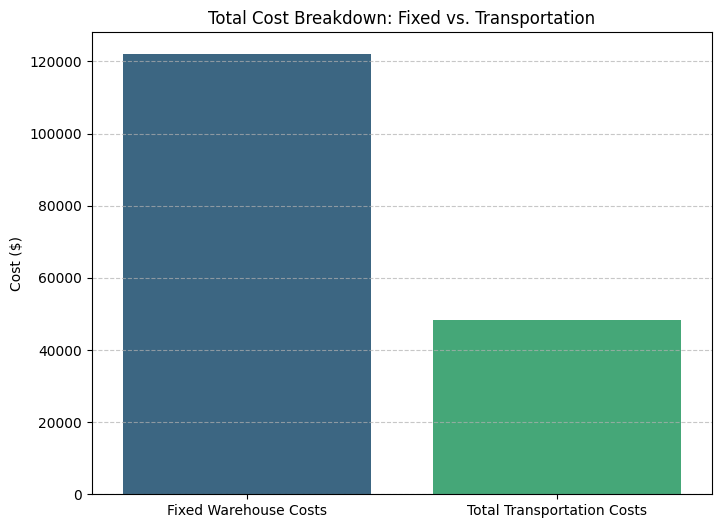

In [22]:
import pulp
import pandas as pd

# Re-initialize the model variables to ensure they are in scope
# Assuming 'demand', 'warehouse', 'cost' dataframes are available from LZnefK-Xknna
C = demand.set_index("City")["Demand"].to_dict()
F = warehouse.set_index("Warehouse")["Fixed"].to_dict()
K = warehouse.set_index("Warehouse")["Capacity"].to_dict()

W = warehouse["Warehouse"].tolist()
L = demand["City"].tolist()

model = pulp.LpProblem("facility_location", pulp.LpMinimize)

open_w = pulp.LpVariable.dicts("open", W, cat="Binary")
ship = pulp.LpVariable.dicts("ship", [(w, l) for w in W for l in L], lowBound=0)

model += pulp.lpSum(F[w] * open_w[w] for w in W) + pulp.lpSum(cost.loc[w, l] * ship[(w, l)] for w in W for l in L)

for l in L:
    model += pulp.lpSum(ship[(w, l)] for w in W) == C[l]

for w in W:
    model += pulp.lpSum(ship[(w, l)] for l in L) <= K[w] * open_w[w]

model.solve()
print("Optimization model variables re-initialized and solved for visualizations.")


# Original code for Visualization 1: Cost Breakdown Bar Chart
# Calculate Fixed Costs
fixed_costs = sum(F[w] for w in W if open_w[w].value() == 1)

# Calculate Transportation Costs
transportation_costs = sum(cost.loc[w, l] * ship[(w, l)].value() for w in W for l in L)

# Create a DataFrame for plotting
cost_data = pd.DataFrame({
    'Cost Type': ['Fixed Warehouse Costs', 'Total Transportation Costs'],
    'Amount': [fixed_costs, transportation_costs]
})

plt.figure(figsize=(8, 6))
sns.barplot(x='Cost Type', y='Amount', data=cost_data, palette='viridis')
plt.title('Total Cost Breakdown: Fixed vs. Transportation')
plt.ylabel('Cost ($)')
plt.xlabel('')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Visualization 2: Warehouse Capacity Utilization
This chart illustrates how much capacity each opened warehouse is utilizing compared to its total available capacity.

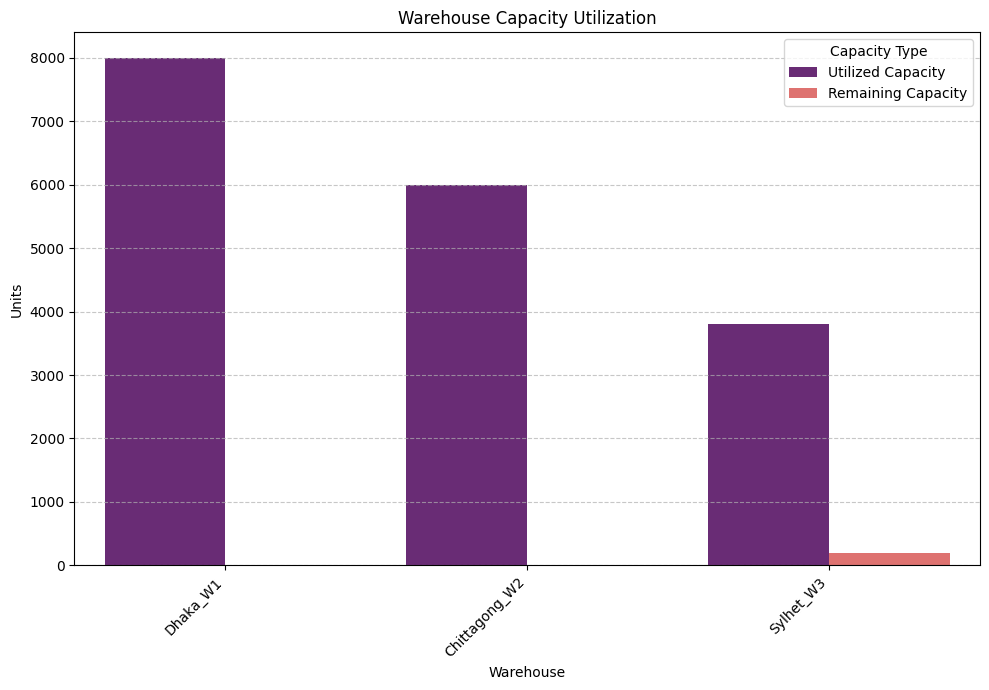

In [13]:
warehouse_capacity_data = []
for w in W:
    if open_w[w].value() == 1:
        total_shipped = sum(ship[(w, l)].value() for l in L)
        warehouse_capacity_data.append({
            'Warehouse': w,
            'Utilized Capacity': total_shipped,
            'Total Capacity': K[w]
        })

capacity_df = pd.DataFrame(warehouse_capacity_data)
capacity_df['Remaining Capacity'] = capacity_df['Total Capacity'] - capacity_df['Utilized Capacity']

capacity_df_melted = capacity_df.melt(id_vars=['Warehouse', 'Total Capacity'],
                                     value_vars=['Utilized Capacity', 'Remaining Capacity'],
                                     var_name='Capacity Type', value_name='Units')

plt.figure(figsize=(10, 7))
sns.barplot(x='Warehouse', y='Units', hue='Capacity Type', data=capacity_df_melted, palette='magma')
plt.title('Warehouse Capacity Utilization')
plt.ylabel('Units')
plt.xlabel('Warehouse')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Capacity Type')
plt.tight_layout()
plt.show()

### Visualization 3: Demand Satisfaction Overview
This bar chart confirms that the demand for each city is fully satisfied.

<Figure size 1200x600 with 0 Axes>

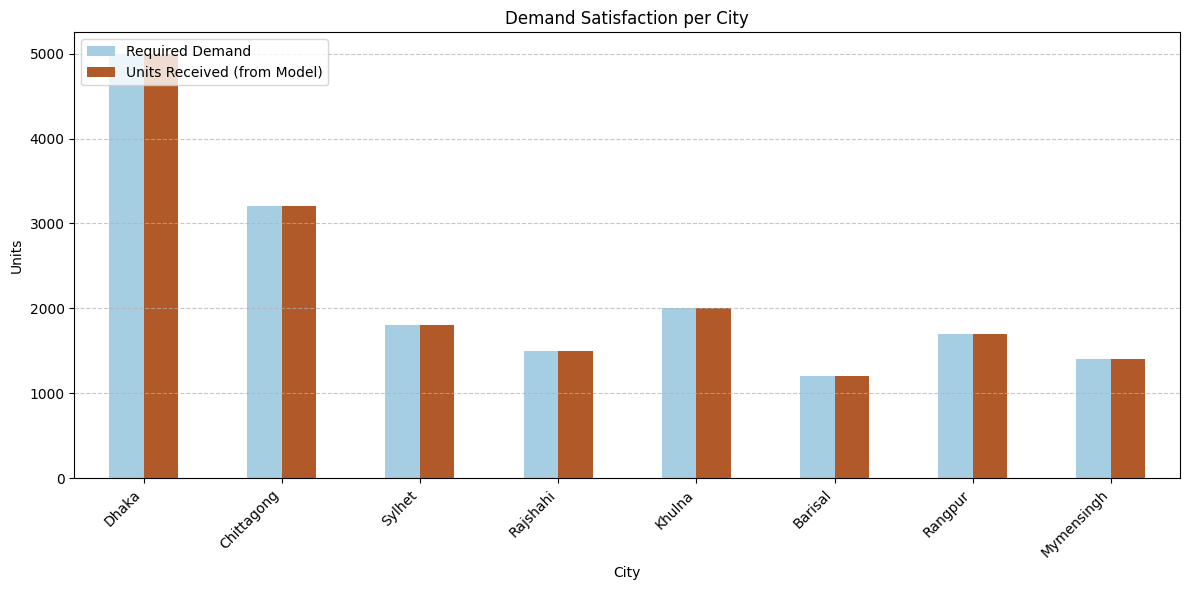

In [14]:
demand_satisfaction_data = []
for l in L:
    total_received = sum(ship[(w, l)].value() for w in W)
    demand_satisfaction_data.append({
        'City': l,
        'Demand': C[l],
        'Units Received': total_received
    })

demand_satisfaction_df = pd.DataFrame(demand_satisfaction_data)

plt.figure(figsize=(12, 6))
demand_satisfaction_df.plot(x='City', y=['Demand', 'Units Received'], kind='bar', figsize=(12, 6), colormap='Paired')
plt.title('Demand Satisfaction per City')
plt.ylabel('Units')
plt.xlabel('City')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(['Required Demand', 'Units Received (from Model)'], loc='upper left')
plt.tight_layout()
plt.show()

### Visualization 4: Shipment Allocation from Open Warehouses to Cities
This stacked bar chart shows which warehouses supply which cities and the quantity shipped.

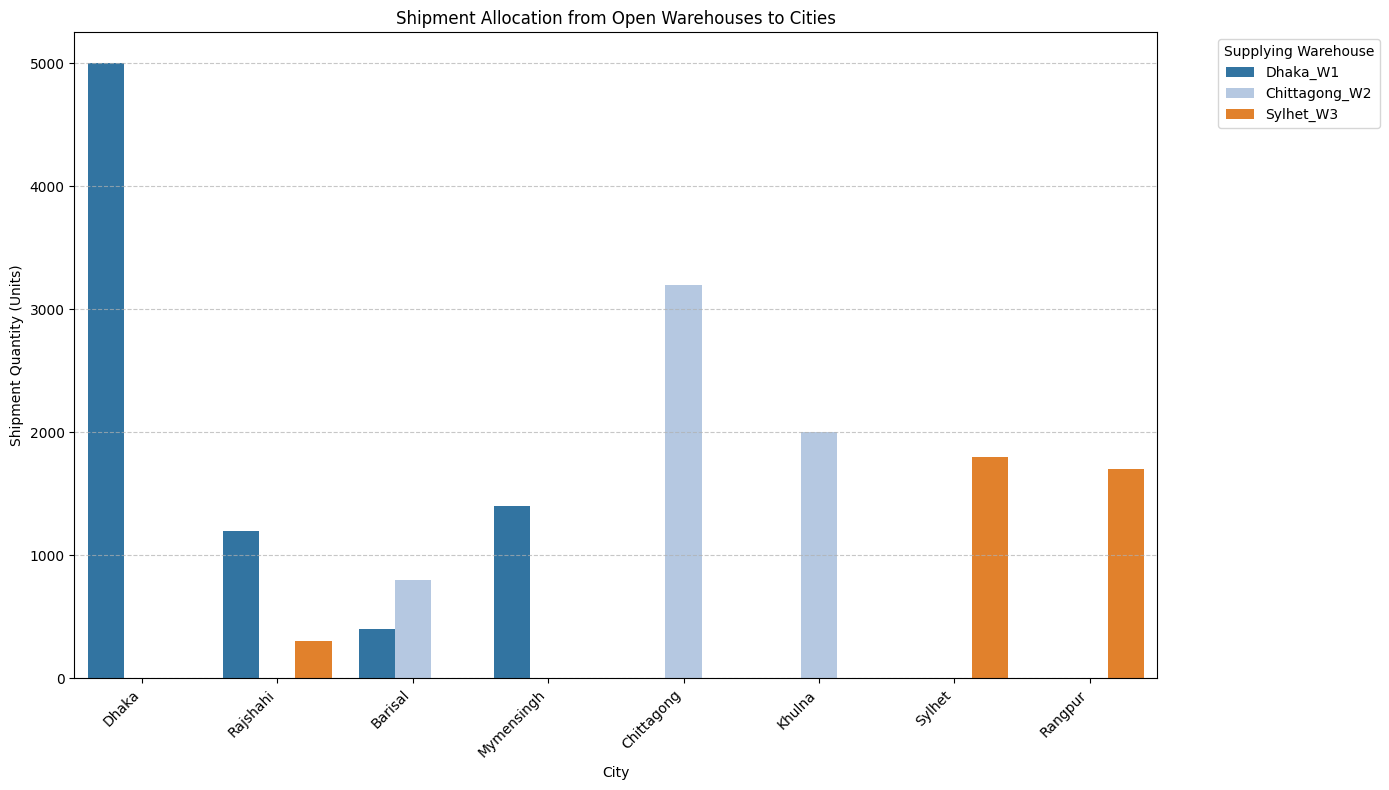

In [15]:
shipment_allocation_data = []
for w in W:
    if open_w[w].value() == 1:
        for l in L:
            if ship[(w, l)].value() > 0:
                shipment_allocation_data.append({
                    'Warehouse': w,
                    'City': l,
                    'Shipment Quantity': ship[(w, l)].value()
                })

shipment_allocation_df = pd.DataFrame(shipment_allocation_data)

plt.figure(figsize=(14, 8))
sns.barplot(x='City', y='Shipment Quantity', hue='Warehouse', data=shipment_allocation_df, palette='tab20')
plt.title('Shipment Allocation from Open Warehouses to Cities')
plt.ylabel('Shipment Quantity (Units)')
plt.xlabel('City')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Supplying Warehouse', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Visualization 5: Total Transportation Cost per Open Warehouse
This bar chart shows the total transportation cost incurred by each open warehouse.

/tmp/ipykernel_927/2867105061.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Warehouse', y='Total Transportation Cost', data=warehouse_transport_costs_df, palette='cubehelix')


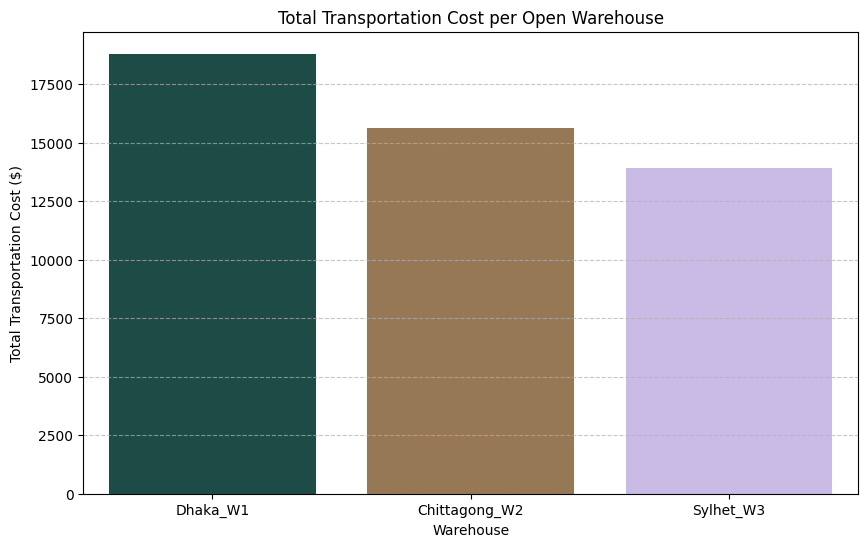

In [16]:
warehouse_transport_costs = []
for w in W:
    if open_w[w].value() == 1:
        total_transport_cost_from_w = sum(cost.loc[w, l] * ship[(w, l)].value() for l in L)
        warehouse_transport_costs.append({
            'Warehouse': w,
            'Total Transportation Cost': total_transport_cost_from_w
        })

warehouse_transport_costs_df = pd.DataFrame(warehouse_transport_costs)

plt.figure(figsize=(10, 6))
sns.barplot(x='Warehouse', y='Total Transportation Cost', data=warehouse_transport_costs_df, palette='cubehelix')
plt.title('Total Transportation Cost per Open Warehouse')
plt.ylabel('Total Transportation Cost ($)')
plt.xlabel('Warehouse')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Results

**Selected warehouses:** 'Dhaka_W1', 'Chittagong_W2', and 'Sylhet_W3'

**Shipment Allocation:**

  Warehouse Dhaka_W1 is open.
  Shipments:

    To Dhaka: 5000.0 units

    To Rajshahi: 1200.0 units

    To Barisal: 400.0 units

    To Mymensingh: 1400.0 units

  Warehouse Chittagong_W2 is
  open. Shipments:

    To Chittagong: 3200.0 units

    To Khulna: 2000.0 units

    To Barisal: 800.0 units

  Warehouse Sylhet_W3 is open.
  Shipments:

    To Sylhet: 1800.0 units

    To Rajshahi: 300.0 units

    To Rangpur: 1700.0 units


**Total cost output:**
Total Cost (Fixed + Transportation): $170,300.00


The solution identifies the most cost-efficient warehouse configuration and optimal distribution plan.

We have created a mathematical decision system that:

Chooses which warehouses to open

Assigns demand from cities to warehouses

Minimizes total cost (fixed + transportation)

Ensures:

All demand is satisfied

Warehouse capacity is not exceeded

This is a classic Mixed Integer Linear Programming (MILP) problem.

# Creating a CSV file to work on PowerBI

In [17]:
# 1. Unpivot the transportation cost matrix
cost_long = cost.reset_index().melt(id_vars='Warehouse',
        var_name='City', value_name='Transportation_cost')

# 2. Merge with warehouse data
merged_data = pd.merge(cost_long, warehouse, on='Warehouse', how='left')

# 3. Merge with demand data
final_supply_chain_df = pd.merge(merged_data, demand, on='City', how='left')

print("Combined Data for Power BI:")
display(final_supply_chain_df.head())

Combined Data for Power BI:


,Warehouse,City,Transportation_cost,Fixed,Capacity,Demand
0,Dhaka_W1,Dhaka,2,50000,8000,5000
1,Chittagong_W2,Dhaka,5,42000,6000,5000
2,Sylhet_W3,Dhaka,6,30000,4000,5000
3,Rajshahi_W4,Dhaka,4,35000,5000,5000
4,Khulna_W5,Dhaka,4,38000,5500,5000


In [18]:
# Save the combined dataframe to a CSV file
output_csv_path = 'network_design_data.csv'
final_supply_chain_df.to_csv(output_csv_path, index=False)

print(f"Data successfully exported to {output_csv_path}")

Data successfully exported to network_design_data.csv
